## Cuaderno con graficas descriptivas marzo 4

In [160]:
import pandas as pd

In [161]:
df_despacho=pd.read_csv('../datos/raw/Despachoprogramadorecursosdegeneracion.csv')
df_desglose = pd.read_excel("../datos/raw/desglose.xlsx",header=3)

In [162]:
df_despacho

,FechaHora,CodigoDuracion,CodigoElementoGeneracion,Valor
0,2025-08-11 00:00:00,PT1H,2QBW,18380
1,2025-08-11 00:00:00,PT1H,2QEK,35000
2,2025-08-11 00:00:00,PT1H,2QRL,650
3,2025-08-11 00:00:00,PT1H,2QV2,6000
4,2025-08-11 00:00:00,PT1H,2R22,18000
...,...,...,...,...
1264514,2025-04-05 23:00:00,PT1H,SLVJ,95000
1264515,2025-04-05 23:00:00,PT1H,SMI1,25000
1264516,2025-04-05 23:00:00,PT1H,SNC1,700
1264517,2025-04-05 23:00:00,PT1H,SNCR,729000


In [163]:
id_termicas=df_desglose[df_desglose['Tipo Generación']=='TERMICA']['Código SIC'].unique()
id_hidraulicas=df_desglose[df_desglose['Tipo Generación']=='HIDRAULICA']['Código SIC'].unique()      
id_solar=df_desglose[df_desglose['Tipo Generación']=='SOLAR']['Código SIC'].unique()

In [164]:
id_termicas

<StringArray>
['5E69', '4YCN', '4XP3', '4T6C', '3NNZ', '3Q99', '3RKP', '3KL4', '3KLQ',
 'TCBE',
 ...
 'PRG2', 'PRG1', 'TGJ2', 'VLL1', 'CTG2', 'CTG1', 'TBQ4', 'TBQ3', 'BRN1',
 'TRM1']
Length: 110, dtype: str

In [165]:
df_despacho['hora']=pd.to_datetime(df_despacho['FechaHora']).dt.hour
df_despacho['fecha']=pd.to_datetime(df_despacho['FechaHora']).dt.date

In [166]:
df_despacho_termica=df_despacho[df_despacho['CodigoElementoGeneracion'].isin(id_termicas)]
df_despacho_hidraulica=df_despacho[df_despacho['CodigoElementoGeneracion'].isin(id_hidraulicas)]
df_despacho_solar=df_despacho[df_despacho['CodigoElementoGeneracion'].isin(id_solar)]

In [167]:
df_despacho_termica['CodigoElementoGeneracion'].nunique()

72

## Despacho por hora

In [168]:
import pandas as pd

def mean_por_hora(df, col_fecha="FechaHora", col_cantidad="Valor"):
    df = df.copy()
    
    # Asegurar datetime
    df[col_fecha] = pd.to_datetime(df[col_fecha])
    
    # 1️⃣ Sumar todas las unidades por timestamp
    df_total = (
        df.groupby(col_fecha)[col_cantidad]
        .sum()
        .reset_index()
    )
    
    # 2️⃣ Extraer hora
    df_total["hora"] = df_total[col_fecha].dt.hour
    
    # 3️⃣ Mean por hora sobre todas las fechas
    df_mean = (
        df_total.groupby("hora")[col_cantidad]
        .mean()
        .reset_index()
    )
    
    return df_mean

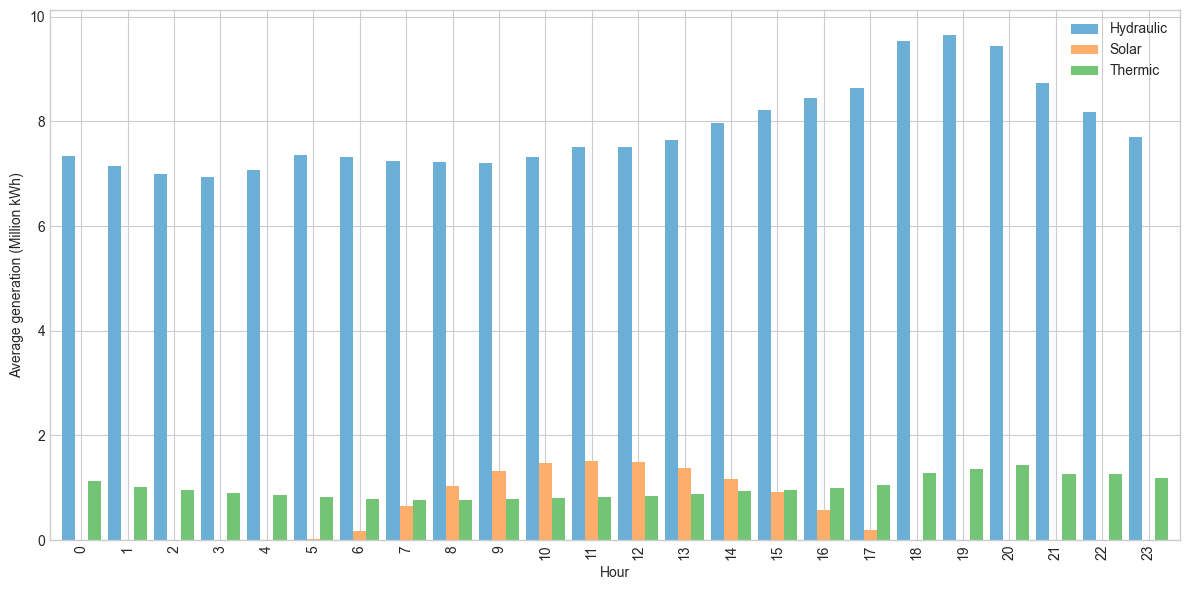

In [169]:
# --- PLOT ---
import matplotlib.pyplot as plt
# Apply function to each technology dataframe
thermic_mean = mean_por_hora(df_despacho_termica)
solar_mean = mean_por_hora(df_despacho_solar)
hydraulic_mean = mean_por_hora(df_despacho_hidraulica)

# Merge results into a single dataframe
df_plot = (
    thermic_mean.rename(columns={"Valor": "Thermic"})
    .merge(
        solar_mean.rename(columns={"Valor": "Solar"}),
        on="hora"
    )
    .merge(
        hydraulic_mean.rename(columns={"Valor": "Hydraulic"}),
        on="hora"
    )
)

# Scale values to millions (1e6)
df_plot[["Thermic", "Solar", "Hydraulic"]] = (
    df_plot[["Thermic", "Solar", "Hydraulic"]] / 1e6
)

# Pastel colors
colors = ["#6baed6", "#fdae6b", "#74c476"]  # hydraulic, solar, thermic  # hydraulic, solar, thermic

df_plot.set_index("hora")[["Hydraulic", "Solar", "Thermic"]].plot(
    kind="bar",
    figsize=(12,6),
    width=0.85,     # thicker bars
    color=colors
)

plt.xlabel("Hour")
plt.ylabel("Average generation (Million kWh)")
plt.legend(["Hydraulic", "Solar", "Thermic"])
plt.tight_layout()
plt.show()

## Despacho por fecha

In [170]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1️⃣ Función para daily dispatch series ---
def daily_dispatch_series(df, col_fecha="FechaHora", col_valor="Valor"):
    """
    Compute daily total dispatch per dataframe.
    Returns a dataframe with 'date' and daily total 'Valor'.
    """
    df = df.copy()
    df[col_fecha] = pd.to_datetime(df[col_fecha])
    
    # Sum over all units per timestamp, then per day
    df_daily = df.groupby(df[col_fecha].dt.date)[col_valor].sum().reset_index()
    df_daily.rename(columns={col_fecha: "date", col_valor: "Valor"}, inplace=True)
    
    return df_daily

# --- 2️⃣ Aplicar a cada tipo de generación ---
thermic_daily = daily_dispatch_series(df_despacho_termica)
solar_daily = daily_dispatch_series(df_despacho_solar)
hydraulic_daily = daily_dispatch_series(df_despacho_hidraulica)

# --- 3️⃣ Unir resultados ---
df_daily_plot = thermic_daily.rename(columns={"Valor": "Thermic"}).merge(
    solar_daily.rename(columns={"Valor": "Solar"}), on="date"
).merge(
    hydraulic_daily.rename(columns={"Valor": "Hydraulic"}), on="date"
)

# Escalar a millones
df_daily_plot[["Thermic", "Solar", "Hydraulic"]] /= 1e6


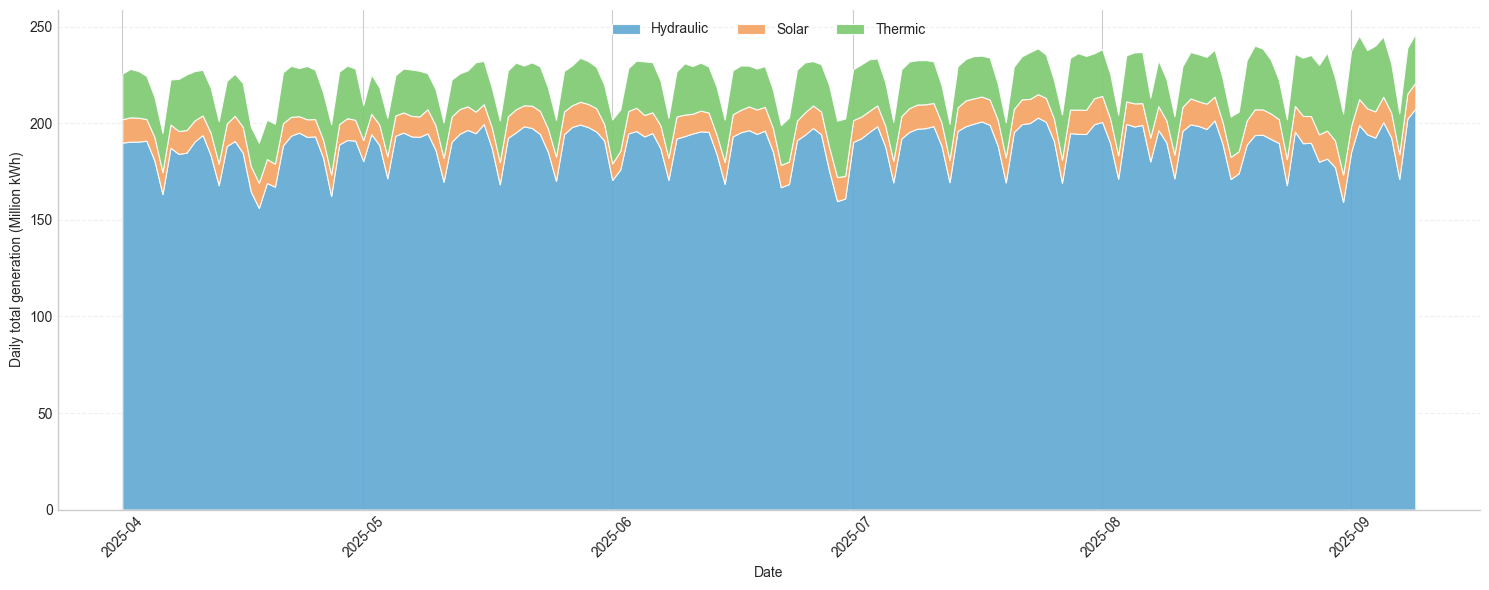

In [171]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Pastel más visible
colors = ["#5fa8d3", "#f4a261", "#7bc96f"]  # Hydro (azul), Solar (naranja), Thermic (verde) # Hydro, Solar, Thermic

plt.stackplot(
    df_daily_plot["date"],
    df_daily_plot["Hydraulic"],
    df_daily_plot["Solar"],
    df_daily_plot["Thermic"],
    labels=["Hydraulic", "Solar", "Thermic"],
    colors=colors,
    alpha=0.9,
    linewidth=0.8,
    edgecolor="white"
)

plt.xlabel("Date")
plt.ylabel("Daily total generation (Million kWh)")

# Pegamos el eje Y al 0
plt.ylim(bottom=0)

plt.legend(loc="upper center", ncol=3, frameon=False)
plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.3)

# Cleaner look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

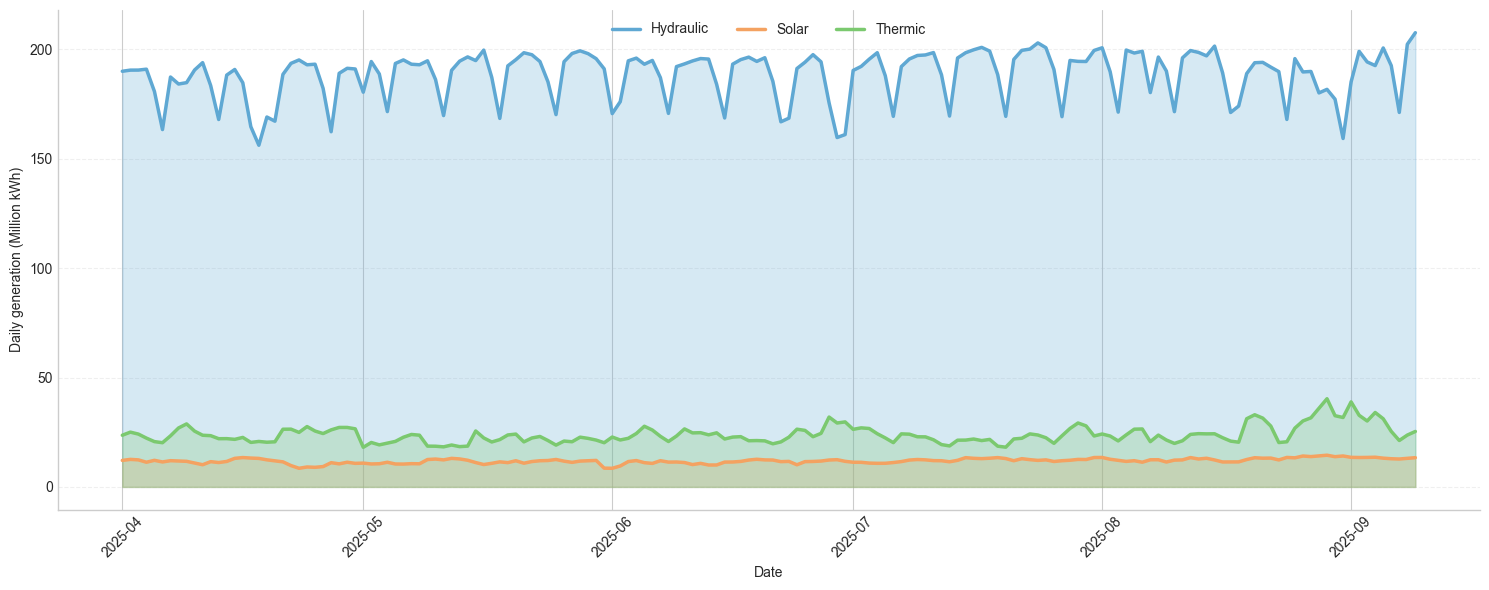

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Colores pastel pero visibles
colors = ["#5fa8d3", "#f4a261", "#7bc96f"]  # Hydro, Solar, Thermic

# Hydro
plt.plot(df_daily_plot["date"], df_daily_plot["Hydraulic"],
         color=colors[0], linewidth=2.5, label="Hydraulic")
plt.fill_between(df_daily_plot["date"], df_daily_plot["Hydraulic"],
                 color=colors[0], alpha=0.25)

# Solar
plt.plot(df_daily_plot["date"], df_daily_plot["Solar"],
         color=colors[1], linewidth=2.5, label="Solar")
plt.fill_between(df_daily_plot["date"], df_daily_plot["Solar"],
                 color=colors[1], alpha=0.25)

# Thermic
plt.plot(df_daily_plot["date"], df_daily_plot["Thermic"],
         color=colors[2], linewidth=2.5, label="Thermic")
plt.fill_between(df_daily_plot["date"], df_daily_plot["Thermic"],
                 color=colors[2], alpha=0.25)

plt.xlabel("Date")
plt.ylabel("Daily generation (Million kWh)")

plt.legend(loc="upper center", ncol=3, frameon=False)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=45)

# Cleaner style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

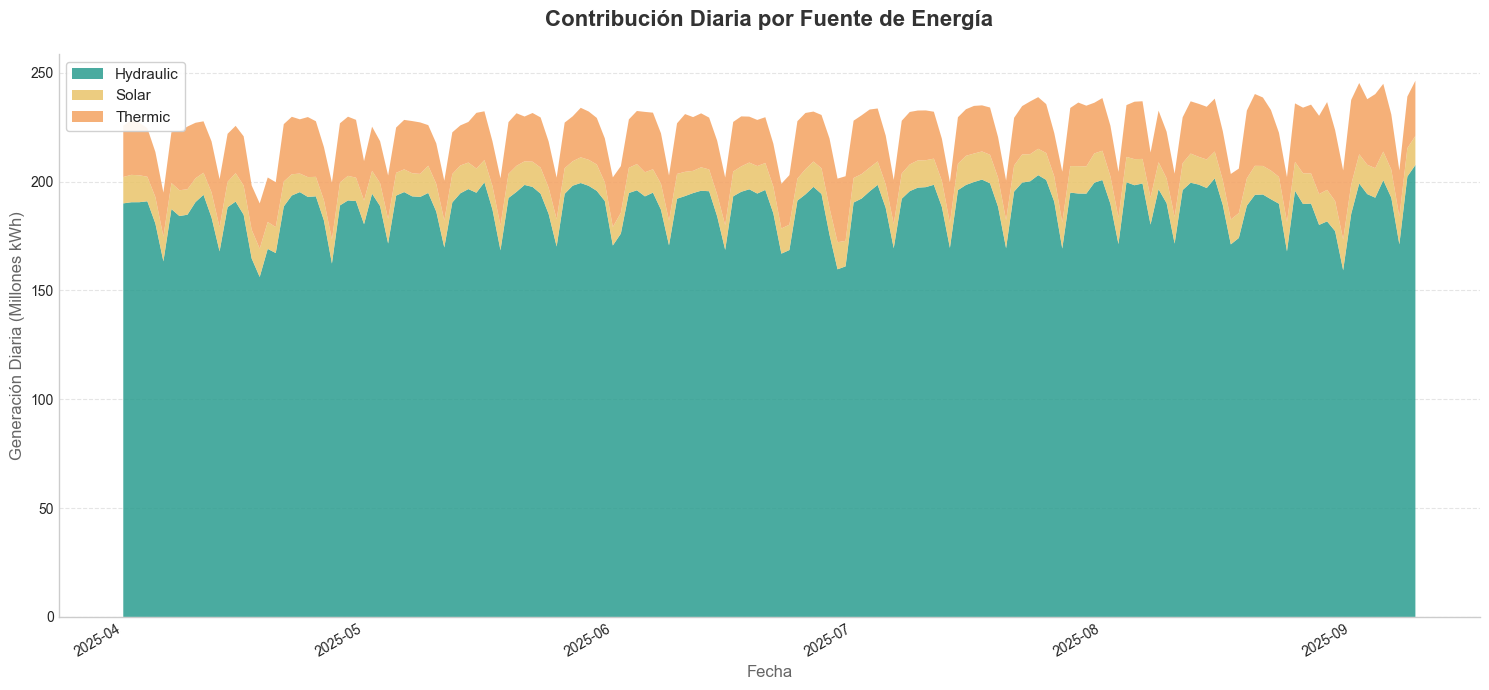

In [173]:
import matplotlib.pyplot as plt

# Configuramos un estilo base más limpio
plt.style.use('seaborn-v0_8-whitegrid') # O simplemente deja el default

plt.figure(figsize=(15, 7))

# Definimos los datos para el stackplot
labels = ["Hydraulic", "Solar", "Thermic"]
# El orden importa: lo más estable suele ir abajo
y = [df_daily_plot["Hydraulic"], df_daily_plot["Solar"], df_daily_plot["Thermic"]]

# Colores modernos y profesionales
colors = ["#2a9d8f", "#e9c46a", "#f4a261"] 

# Creamos el gráfico de áreas apiladas
plt.stackplot(df_daily_plot["date"], y, labels=labels, colors=colors, alpha=0.85)

# --- ESTÉTICA Y DETALLES ---

# Título y etiquetas con una fuente más elegante
plt.title("Contribución Diaria por Fuente de Energía", fontsize=16, pad=20, fontweight='bold', color='#333333')
plt.xlabel("Fecha", fontsize=12, color='#666666')
plt.ylabel("Generación Diaria (Millones kWh)", fontsize=12, color='#666666')

# Ajustamos la leyenda para que no estorbe
plt.legend(loc="upper left", frameon=True, facecolor='white', framealpha=0.9, fontsize=11)

# Limpiamos los bordes (spines)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Mejoramos la cuadrícula: solo horizontal y muy sutil
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.2)
ax.xaxis.grid(False)

# Rotación de fechas para mejor lectura
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('grafica_energia.png', dpi=300) # Para alta calidad
plt.show()

### Marzo 26

In [174]:
df_input_red = pd.read_csv(
    "../results/fechas_117/TERMICA/inputRed.csv",
    sep=";",
    decimal=","
)
df_input_red['CodigoPlanta'].nunique()

36

In [175]:
df_desglose = pd.read_excel("../datos/raw/desglose.xlsx", header=3)
df_desglose

,Código SIC,Nombre Recurso,Capacidad Efectiva Neta [MW],Factor de Conversión,Es Menor,Tipo Despacho,Combustible por Defecto,Fecha Operación,Municipio,Departamento,Agente Representante,Estado Recurso,Tipo Generación,Clasificación
0,5E69,TERMOSARAVENA 1,4.9,10.7650,SI,ND,GAS,2025-10-31,SARAVENA,ARAUCA,GENERSA S.A.S. E.S.P.,PRUEBAS,TERMICA,AUTOGENERADOR
1,4YCN,VILLANUEVA 1,25.0,11.9149,NO,DC,BIOMASA,2025-10-02,VILLANUEVA,CASANARE,REFOENERGY VILLANUEVA S.A.S E.S.P.,OPERACIÓN,TERMICA,NORMAL
2,4XP3,AUTOG TERMOARAUCA 1,4.9,10.7650,NO,ND,GAS,2025-08-27,SARAVENA,ARAUCA,GENERSA S.A.S. E.S.P.,OPERACIÓN,TERMICA,AUTOGENERADOR
3,4T6C,AUTOG LOS POCITOS 1,4.1,4.3900,NO,ND,BIOGAS,2025-02-16,TUBARA,ATLÁNTICO,BCCY CORDOBA S.A.S. E.S.P.,OPERACIÓN,TERMICA,AUTOGENERADOR
4,3NNZ,AUTOG TERMOCOROCITO 1,4.9,0.0000,NO,ND,GAS,2024-10-29,TAME,ARAUCA,GENERSA S.A.S. E.S.P.,OPERACIÓN,TERMICA,AUTOGENERADOR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,ILC1,INGENIO LA CARMELITA,0.0,0.0000,NO,ND,BAGAZO,2009-11-11,TULUA,VALLE DEL CAUCA,DEPI ENERGY S.A.S. E.S.P.,INACTIVO,COGENERADOR,COGENERADOR
503,CIP1,INGENIO PROVIDENCIA 2,19.9,0.0000,NO,ND,CARBON,2009-05-18,EL CERRITO,VALLE DEL CAUCA,NITRO ENERGY COLOMBIA S.A.S. E.S.P.,OPERACIÓN,COGENERADOR,COGENERADOR
504,PPN1,PAPELES NACIONALES,0.0,0.0000,NO,ND,GAS,2009-02-05,PEREIRA,RISARALDA,ENERCO S.A. E.S.P.,OPERACIÓN,COGENERADOR,COGENERADOR
505,CAS1,CENTRAL CASTILLA 1,3.0,0.0000,NO,ND,BAGAZO,2004-08-15,PRADERA,VALLE DEL CAUCA,RIOPAILA ENERGÍA S.A.S. E.S.P.,OPERACIÓN,COGENERADOR,COGENERADOR


In [176]:
import pandas as pd

df_desglose = pd.read_excel("../datos/raw/desglose.xlsx", header=3)

tipos_generacion = ['TERMICA', 'HIDRAULICA', 'SOLAR']

df_desglose = df_desglose[
    (df_desglose['Tipo Generación'].isin(tipos_generacion)) &
    (df_desglose['Estado Recurso'] == 'OPERACIÓN') &
    (df_desglose['Tipo Despacho'] == 'DC')
].copy()



# Resumen por tipo de generación
resumen = df_desglose.groupby('Tipo Generación')['Nombre Recurso'].nunique().reset_index()
resumen.rename(columns={'Nombre Recurso': 'Total Recursos'}, inplace=True)
print(resumen)



  Tipo Generación  Total Recursos
0      HIDRAULICA              30
1           SOLAR              11
2         TERMICA              40


In [177]:
resumen_tipo_generacion = df_desglose.groupby('Tipo Generación').agg(
    num_agentes=('Agente Representante', 'nunique'),
    num_recursos=('Nombre Recurso', 'nunique')
).reset_index()

print(resumen_tipo_generacion)

  Tipo Generación  num_agentes  num_recursos
0      HIDRAULICA            7            30
1           SOLAR            8            11
2         TERMICA           20            40


In [178]:
df_termicas = df_desglose[df_desglose['Tipo Generación'] == 'TERMICA'].copy()

conteo_recursos_por_agente = df_termicas.groupby('Agente Representante')['Nombre Recurso'].nunique()

resumen_recursos = conteo_recursos_por_agente.value_counts().reset_index()
resumen_recursos.columns = ['num_recursos', 'num_agentes']

print(resumen_recursos.sort_values('num_recursos'))

   num_recursos  num_agentes
0             1           10
1             2            4
2             3            3
3             4            2
4             5            1


In [179]:
df_termicas['Código SIC'].unique()

<StringArray>
['4YCN', 'TCBE', 'TYP5', 'TYP4', 'TYP3', 'GE32', 'TSJ2', 'GEC3', 'TDR1',
 'PPA3', 'PPA2', 'PPA1', 'TGJ1', 'CTG3', 'TYP1', 'TYP2', '3ENA', 'TCDT',
 'TFL4', 'TRN1', 'TFL1', 'TSR1', 'TVL1', 'TEC1', 'TBST', 'PPA4', 'MRL1',
 'ZPA5', 'ZPA4', 'ZPA3', 'ZPA2', 'TSJ1', 'PRG2', 'PRG1', 'TGJ2', 'CTG2',
 'CTG1', 'TBQ4', 'TBQ3', 'TRM1']
Length: 40, dtype: str

In [180]:
df_input_red['CodigoPlanta'].unique()

<StringArray>
['TYP3', 'TYP2', 'TSJ2', 'TSJ1', 'MRL1', 'PPA1', 'TYP1', 'TYP4', 'GE32',
 'PPA4', 'PPA2', 'PPA3', 'GEC3', 'ZPA5', 'ZPA2', 'TSR1', 'ZPA3', 'TRM1',
 'TGJ1', 'TGJ2', 'TFL1', 'TFL4', 'PRG2', 'PRG1', 'TDR1', 'ZPA4', 'CTG1',
 'CTG2', '3ENA', 'TCDT', 'TBST', 'TRN1', 'TBQ4', 'TBQ3', 'TVL1', 'TEC1']
Length: 36, dtype: str

In [181]:
archivo = "../datos/raw/PreciodeOfertaDeclarado.csv"
df_declarado = pd.read_csv(archivo, sep=";", encoding="utf-8")
df_declarado= pd.merge(df_declarado, df_desglose[['Código SIC', 'Tipo Generación']], left_on='CodigoPlanta', right_on='Código SIC')
df_declarado[df_declarado['Tipo Generación'] == 'TERMICA']['CodigoPlanta'].nunique()

38

In [182]:
df_termicas = df_declarado[df_declarado['Tipo Generación'] == 'TERMICA']
config_por_planta = df_termicas.groupby('CodigoPlanta')['Configuracion'].nunique()
resumen = config_por_planta.value_counts().sort_index()
resumen

Configuracion
1     31
2      1
4      3
5      1
10     1
14     1
Name: count, dtype: int64

In [183]:
import pandas as pd

archivo_oferta = "../datos/raw/Preciodeofertaplanta.csv"
df_oferta = pd.read_csv(archivo_oferta, sep=",", encoding="utf-8")

df_oferta['fecha'] = pd.to_datetime(df_oferta['FechaHora']).dt.date

df_oferta_grouped = df_oferta.groupby(['fecha', 'CodigoPlanta'])['Valor'].mean().reset_index()
df_oferta_grouped= pd.merge(df_oferta_grouped, df_desglose[['Código SIC', 'Tipo Generación']], left_on='CodigoPlanta', right_on='Código SIC')
df_oferta_grouped[df_oferta_grouped['Tipo Generación'] == 'TERMICA']['CodigoPlanta'].nunique()

39

## Cantidades

In [184]:
archivo_plantas = "../datos/raw/Listado_Recursos_Generacion.xlsx"
df_plantas = pd.read_excel(archivo_plantas,header=3)

tipos_generacion = ['TERMICA', 'HIDRAULICA', 'SOLAR']

df_plantas = df_plantas[
    (df_plantas['Tipo Generación'].isin(tipos_generacion)) &
    (df_plantas['Estado Recurso'] == 'OPERACIÓN') &
    (df_plantas['Tipo Despacho'] == 'DC')
].copy()



# Resumen por tipo de generación
resumen = df_plantas.groupby('Tipo Generación')['Nombre Recurso'].nunique().reset_index()
resumen.rename(columns={'Nombre Recurso': 'Total Recursos'}, inplace=True)
print(resumen)

  Tipo Generación  Total Recursos
0      HIDRAULICA              30
1           SOLAR              11
2         TERMICA              40


In [185]:
julio = pd.read_csv("../datos/raw/Disponibilidadcomercialporplantajulio.csv", sep=',', encoding='utf-8')
septiembre = pd.read_csv("../datos/raw/Disponibilidadcomercialporplantaseptiembre.csv", sep=',', encoding='utf-8')
# Concatenar verticalmente
df_capacity = pd.concat([julio, septiembre], axis=0)
# Eliminar duplicados exactos
df_capacity = df_capacity.drop_duplicates()
df_capacity = df_capacity.reset_index(drop=True)
df_capacity= pd.merge(df_capacity, df_desglose[['Código SIC', 'Tipo Generación']], left_on='CodigoPlanta', right_on='Código SIC')


In [186]:
df_capacity

,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,Version,Valor,CodigoPlanta,Código SIC,Tipo Generación
0,DispCom,2025-05-25 23:00:00,PT1H,kWh,TX3,15000.0,ESMR,ESMR,HIDRAULICA
1,DispCom,2025-05-25 22:00:00,PT1H,kWh,TX3,15000.0,ESMR,ESMR,HIDRAULICA
2,DispCom,2025-05-25 21:00:00,PT1H,kWh,TX3,15000.0,ESMR,ESMR,HIDRAULICA
3,DispCom,2025-05-25 20:00:00,PT1H,kWh,TX3,15000.0,ESMR,ESMR,HIDRAULICA
4,DispCom,2025-05-25 19:00:00,PT1H,kWh,TX3,15000.0,ESMR,ESMR,HIDRAULICA
...,...,...,...,...,...,...,...,...,...
714669,DispCom,2025-08-10 10:00:00,PT1H,kWh,TX1,63000.0,TPUY,TPUY,SOLAR
714670,DispCom,2025-08-10 09:00:00,PT1H,kWh,TX1,64000.0,TPUY,TPUY,SOLAR
714671,DispCom,2025-08-10 08:00:00,PT1H,kWh,TX1,50000.0,TPUY,TPUY,SOLAR
714672,DispCom,2025-08-10 07:00:00,PT1H,kWh,TX1,42000.0,TPUY,TPUY,SOLAR


In [187]:
df_capacity_termicas_cero = df_capacity[
    (df_capacity['Tipo Generación'] == 'TERMICA') &
    (df_capacity['Valor'] == 0)
]
df_capacity_termicas_cero

,CodigoVariable,FechaHora,CodigoDuracion,UnidadMedida,Version,Valor,CodigoPlanta,Código SIC,Tipo Generación


In [188]:
df_input_estimacion = pd.read_csv("../datos/procesado/df_final.csv")
df_input_estimacion= pd.merge(df_input_estimacion, df_desglose[['Código SIC', 'Tipo Generación']], left_on='CodigoPlanta', right_on='Código SIC')

In [189]:
df_input_estimacion[df_input_estimacion['Tipo Generación'] == 'TERMICA']['CodigoPlanta'].unique()

<StringArray>
['TEC1', 'TCBE', 'TDR1', 'PRG1', 'PPA1', 'TFL4', 'ZPA4', 'TYP4', 'ZPA3',
 'TYP2', 'ZPA5', 'GEC3', '3ENA', 'TYP3', 'TVL1', 'TSJ1', 'TRM1', 'TBST',
 'CTG3', 'CTG2', 'GE32', 'TCDT', 'PPA4', 'MRL1', 'CTG1', 'TBQ4', 'TRN1',
 'TYP1', 'PPA3', 'PPA2', 'TSR1', 'TGJ2', 'PRG2', 'TSJ2', 'TFL1', 'TGJ1',
 'TBQ3', 'TYP5', 'ZPA2']
Length: 39, dtype: str

## inicialmente tenia 39 que declaran cierto pero despues en cantidades puede tener 0 entonces simplemente lo saco y quedan 36 termicas

In [190]:
df_input_estimacion[df_input_estimacion['cantidad']==0]

,FechaHora,CodigoPlanta,precio,cantidad,cantidad_pos,Fecha,cluster,gamma_thumb,Código SIC,Tipo Generación
24,2025-05-25 23:00:00,TCBE,892.39,0.0,0.0,2025-05-25,6,0.0,TCBE,TERMICA
25,2025-05-25 22:00:00,TCBE,892.39,0.0,0.0,2025-05-25,6,0.0,TCBE,TERMICA
26,2025-05-25 21:00:00,TCBE,892.39,0.0,0.0,2025-05-25,6,0.0,TCBE,TERMICA
27,2025-05-25 20:00:00,TCBE,892.39,0.0,0.0,2025-05-25,6,0.0,TCBE,TERMICA
28,2025-05-25 19:00:00,TCBE,892.39,0.0,0.0,2025-05-25,6,0.0,TCBE,TERMICA
...,...,...,...,...,...,...,...,...,...,...
221803,2025-09-05 04:00:00,TYP5,93.44,0.0,0.0,2025-09-05,2,0.0,TYP5,TERMICA
221804,2025-09-05 03:00:00,TYP5,93.44,0.0,0.0,2025-09-05,2,0.0,TYP5,TERMICA
221805,2025-09-05 02:00:00,TYP5,93.44,0.0,0.0,2025-09-05,2,0.0,TYP5,TERMICA
221806,2025-09-05 01:00:00,TYP5,93.44,0.0,0.0,2025-09-05,2,0.0,TYP5,TERMICA


In [191]:
df_input_estimacion= df_input_estimacion[df_input_estimacion['cantidad']!=0]
df_input_estimacion[df_input_estimacion['Tipo Generación'] == 'TERMICA']['CodigoPlanta'].unique()

<StringArray>
['TEC1', 'TDR1', 'PPA1', 'TFL4', 'ZPA4', 'TYP4', 'ZPA3', 'TYP2', 'ZPA5',
 'GEC3', '3ENA', 'TYP3', 'TVL1', 'TBST', 'CTG2', 'TCDT', 'PPA4', 'MRL1',
 'CTG1', 'TBQ4', 'TRN1', 'TYP1', 'PPA3', 'PPA2', 'TSR1', 'TGJ2', 'TSJ2',
 'TGJ1', 'TBQ3', 'ZPA2', 'TSJ1', 'GE32', 'TFL1', 'PRG1', 'TRM1', 'PRG2']
Length: 36, dtype: str

In [192]:
df_result = pd.read_csv("../results/fechas_117/df_20250401_to_20250909_M20_preproc.csv")
df_result= pd.merge(df_result, df_desglose[['Código SIC', 'Tipo Generación']], left_on='CodigoPlanta', right_on='Código SIC')
df_result[df_result['Tipo Generación'] == 'TERMICA']['CodigoPlanta'].unique()


<StringArray>
['TEC1', 'TDR1', 'PPA1', 'TFL4', 'ZPA4', 'TYP4', 'ZPA3', 'TYP2', 'ZPA5',
 'GEC3', '3ENA', 'TYP3', 'TVL1', 'TBST', 'CTG2', 'TCDT', 'PPA4', 'MRL1',
 'CTG1', 'TBQ4', 'TRN1', 'TYP1', 'PPA3', 'PPA2', 'TSR1', 'TGJ2', 'TSJ2',
 'TGJ1', 'TBQ3', 'ZPA2', 'TSJ1', 'GE32', 'TFL1', 'PRG1', 'TRM1', 'PRG2']
Length: 36, dtype: str

## De este si verificamos que se cumplan!!!!! FINAL FINAL VERIFICACION

In [193]:
resumen = df_result.groupby('Tipo Generación')['CodigoPlanta'].nunique().reset_index() 
resumen.rename(columns={'Nombre Recurso': 'Total Recursos'}, inplace=True) 
print(resumen)

  Tipo Generación  CodigoPlanta
0      HIDRAULICA            30
1           SOLAR            10
2         TERMICA            36


In [194]:
df_result

,FechaHora,CodigoPlanta,precio,cantidad,cantidad_pos,Fecha,cluster,gamma_thumb,EQpos,EdQb,Código SIC,Tipo Generación
0,2025-05-25 23:00:00,TEC1,1486.46,213000.0,213000.0,2025-05-25,6,0.747557,213000.0,-2527.568103,TEC1,TERMICA
1,2025-05-25 22:00:00,TEC1,1486.46,213000.0,213000.0,2025-05-25,6,0.747557,213000.0,-2158.158396,TEC1,TERMICA
2,2025-05-25 21:00:00,TEC1,1486.46,213000.0,213000.0,2025-05-25,6,0.747557,213000.0,-331.009315,TEC1,TERMICA
3,2025-05-25 20:00:00,TEC1,1486.46,213000.0,213000.0,2025-05-25,6,0.747557,213000.0,-1495.265048,TEC1,TERMICA
4,2025-05-25 19:00:00,TEC1,1486.46,213000.0,213000.0,2025-05-25,6,0.747557,213000.0,-2003.898305,TEC1,TERMICA
...,...,...,...,...,...,...,...,...,...,...,...,...
176189,2025-09-05 04:00:00,ZPA2,372.94,36000.0,36000.0,2025-09-05,2,1.166288,36000.0,-1016.016958,ZPA2,TERMICA
176190,2025-09-05 03:00:00,ZPA2,372.94,36000.0,36000.0,2025-09-05,2,1.166288,36000.0,-759.712344,ZPA2,TERMICA
176191,2025-09-05 02:00:00,ZPA2,372.94,36000.0,36000.0,2025-09-05,2,1.166288,36000.0,-604.754684,ZPA2,TERMICA
176192,2025-09-05 01:00:00,ZPA2,372.94,36000.0,36000.0,2025-09-05,2,1.166288,36000.0,-2640.364614,ZPA2,TERMICA


C:\Users\HP\AppData\Local\Temp\ipykernel_16400\2088212083.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado, x='Tipo Generación', y='precio', palette=["#74c476", "#fdae6b", "#6baed6"])


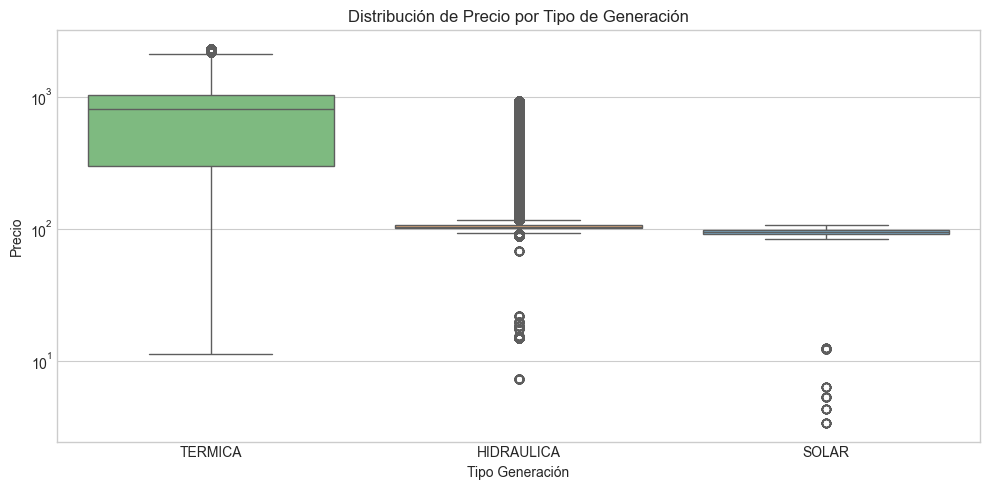

C:\Users\HP\AppData\Local\Temp\ipykernel_16400\2088212083.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtrado, x='Tipo Generación', y=df_filtrado['cantidad']/1000, palette=["#74c476", "#fdae6b", "#6baed6"])


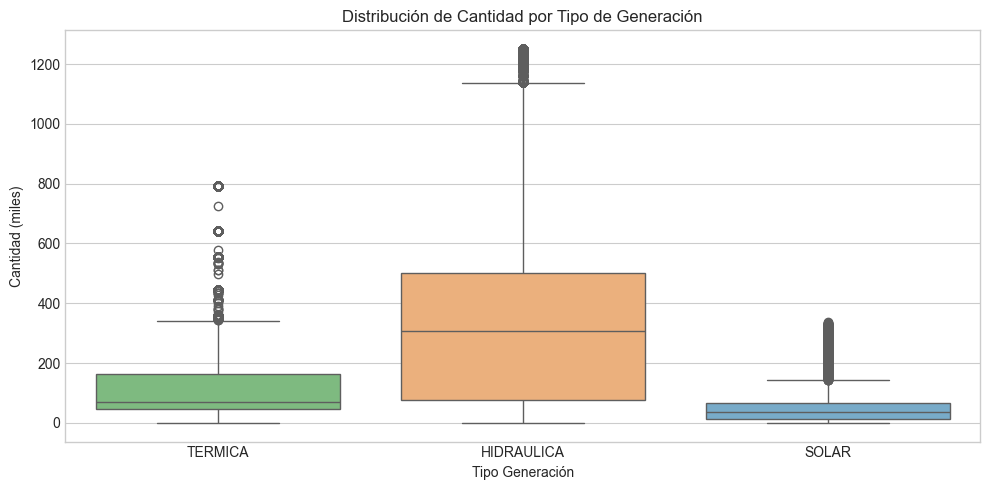

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtrado = df_result[(df_result['precio'] > 0) & (df_result['cantidad'] > 0)]

# --- Boxplot Precio ---
plt.figure(figsize=(10,5))
sns.boxplot(data=df_filtrado, x='Tipo Generación', y='precio', palette=["#74c476", "#fdae6b", "#6baed6"])
plt.yscale('log')  # si quieres ver mejor los outliers
plt.ylabel("Precio")
plt.title("Distribución de Precio por Tipo de Generación")
plt.tight_layout()
plt.show()

# --- Boxplot Cantidad (dividida entre 1,000 para miles) ---
plt.figure(figsize=(10,5))
sns.boxplot(data=df_filtrado, x='Tipo Generación', y=df_filtrado['cantidad']/1000, palette=["#74c476", "#fdae6b", "#6baed6"])
plt.ylabel("Cantidad (miles)")
plt.title("Distribución de Cantidad por Tipo de Generación")
plt.tight_layout()
plt.show()

In [196]:
df_filtrado['precio'].describe()

count    176119.000000
mean        442.666571
std         496.029805
min           3.360000
25%         101.190000
50%         144.710000
75%         781.230000
max        2313.830000
Name: precio, dtype: float64

In [197]:
df_filtrado = df_result[(df_result['precio'] > 0) & (df_result['cantidad'] > 0)]

resumen_stats = df_filtrado.groupby('Tipo Generación').agg(
    Total_Plantas=('CodigoPlanta', 'nunique'),
    Precio_min=('precio', 'min'),
    Precio_max=('precio', 'max'),
    Precio_mean=('precio', 'mean'),
    Precio_std=('precio', 'std'),
    Cantidad_min=('cantidad', 'min'),
    Cantidad_max=('cantidad', 'max'),
    Cantidad_mean=('cantidad', 'mean'),
    Cantidad_std=('cantidad', 'std')
).reset_index()

resumen_stats

,Tipo Generación,Total_Plantas,Precio_min,Precio_max,Precio_mean,Precio_std,Cantidad_min,Cantidad_max,Cantidad_mean,Cantidad_std
0,HIDRAULICA,30,7.27,928.37,138.973700,124.746122,40.61,1250000.0,362598.731711,334564.428534
1,SOLAR,10,3.36,107.37,93.965782,9.000954,1.88,336000.0,49964.923682,54395.000237
2,TERMICA,36,11.27,2313.83,785.035257,528.292932,0.01,791000.0,146355.647931,161583.312758


In [198]:
id_termica = df_result[df_result['Tipo Generación'] == 'TERMICA']['CodigoPlanta'].unique()
id_hidraulica = df_result[df_result['Tipo Generación'] == 'HIDRAULICA']['CodigoPlanta'].unique()
id_solar = df_result[df_result['Tipo Generación'] == 'SOLAR']['CodigoPlanta'].unique()

id_termica, id_hidraulica, id_solar

(<StringArray>
 ['TEC1', 'TDR1', 'PPA1', 'TFL4', 'ZPA4', 'TYP4', 'ZPA3', 'TYP2', 'ZPA5',
  'GEC3', '3ENA', 'TYP3', 'TVL1', 'TBST', 'CTG2', 'TCDT', 'PPA4', 'MRL1',
  'CTG1', 'TBQ4', 'TRN1', 'TYP1', 'PPA3', 'PPA2', 'TSR1', 'TGJ2', 'TSJ2',
  'TGJ1', 'TBQ3', 'ZPA2', 'TSJ1', 'GE32', 'TFL1', 'PRG1', 'TRM1', 'PRG2']
 Length: 36, dtype: str,
 <StringArray>
 ['ESMR', 'URA1', 'CLMG', '2QEK', 'DVS1', 'SNFR', 'LTSJ', 'CHVR', 'PGUG',
  'SNCR', 'PRC3', 'HMLG', 'GTRG', 'CUC1', 'SOG1', 'MOY1', 'SMI1', 'ALBG',
  'PRDO', 'CHBG', 'HMIN', 'SLVJ', 'PES1', 'PLYS', 'CLL1', 'GTPE', 'QUI1',
  'JAGS', 'GVIO', 'PRC2']
 Length: 30, dtype: str,
 <StringArray>
 ['3IQA', '3IZ6', 'GYPO', '3INX', '3IRX', 'MATA', '3HF5', 'EPFV', 'TPUY',
  '3DDT']
 Length: 10, dtype: str)

## Ahora mirando si es muchos generadores por firma

In [199]:
import pandas as pd

df_desglose = pd.read_excel("../datos/raw/desglose.xlsx", header=3)

df_desglose = df_desglose[
    df_desglose['Código SIC'].isin(list(id_termica) + list(id_hidraulica) + list(id_solar))
]
df_desglose

,Código SIC,Nombre Recurso,Capacidad Efectiva Neta [MW],Factor de Conversión,Es Menor,Tipo Despacho,Combustible por Defecto,Fecha Operación,Municipio,Departamento,Agente Representante,Estado Recurso,Tipo Generación,Clasificación
20,TYP4,TERMOYOPAL G4,50.0,8.3937,NO,DC,GAS,2020-08-31,YOPAL,CASANARE,TERMOYOPAL GENERACION 2 S.A.S E.S.P.,OPERACIÓN,TERMICA,NORMAL
21,TYP3,TERMOYOPAL G3,50.0,8.4932,NO,DC,GAS,2020-08-31,YOPAL,CASANARE,TERMOYOPAL GENERACION 2 S.A.S E.S.P.,OPERACIÓN,TERMICA,NORMAL
27,GE32,GECELCA 32,270.0,10.2484,NO,DC,CARBON,2018-09-28,PTO. LIBERTADOR,CÓRDOBA,GENERADORA Y COMERCIALIZADORA DE ENERGIA DEL C...,OPERACIÓN,TERMICA,NORMAL
33,TSJ2,TASAJERO 2,170.0,10.1502,NO,DC,CARBON,2015-11-30,SAN CAYETANO,NORTE DE SANTANDER,TERMOTASAJERO DOS S.A. E.S.P.,OPERACIÓN,TERMICA,NORMAL
35,GEC3,GECELCA 3,164.0,10.1434,NO,DC,CARBON,2015-09-17,PTO. LIBERTADOR,CÓRDOBA,GENERADORA Y COMERCIALIZADORA DE ENERGIA DEL C...,OPERACIÓN,TERMICA,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,SMI1,SAN MIGUEL,50.0,1.4068,NO,DC,AGUA,2015-12-23,SAN LUIS,ANTIOQUIA,ISAGEN S.A. E.S.P.,OPERACIÓN,HIDRAULICA,FILO DE AGUA
480,PGUG,PAGUA,600.0,16.0307,NO,DC,AGUA,1986-12-01,LA MESA,CUNDINAMARCA,ENEL COLOMBIA SA ESP,OPERACIÓN,HIDRAULICA,NORMAL
494,PRDO,PRADO,51.0,0.4966,NO,DC,AGUA,1973-03-01,PRADO,TOLIMA,CELSIA COLOMBIA S.A. E.S.P.,OPERACIÓN,HIDRAULICA,NORMAL
496,GVIO,GUAVIO,1250.0,9.8367,NO,DC,AGUA,1993-03-19,UBALA,CUNDINAMARCA,ENEL COLOMBIA SA ESP,OPERACIÓN,HIDRAULICA,NORMAL


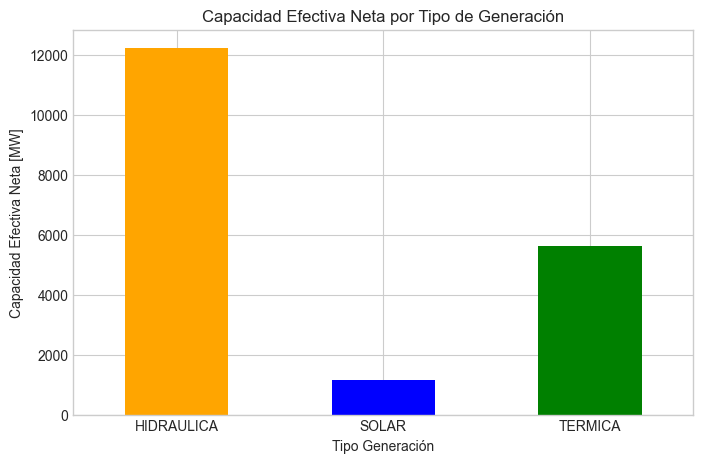

In [200]:
import matplotlib.pyplot as plt

# Sumar capacidad por tipo de generación
capacidad_por_tipo = df_desglose.groupby('Tipo Generación')['Capacidad Efectiva Neta [MW]'].sum()

# Crear gráfico de barras
plt.figure(figsize=(8,5))
capacidad_por_tipo.plot(kind='bar', color=['orange', 'blue', 'green'])
plt.ylabel('Capacidad Efectiva Neta [MW]')
plt.title('Capacidad Efectiva Neta por Tipo de Generación')
plt.xticks(rotation=0)
plt.show()

In [201]:
capacidad_por_tipo = df_desglose.groupby('Tipo Generación')['Capacidad Efectiva Neta [MW]'].sum().reset_index()
capacidad_por_tipo.rename(columns={'Capacidad Efectiva Neta [MW]': 'Total Capacidad [MW]'}, inplace=True)

capacidad_por_tipo

,Tipo Generación,Total Capacidad [MW]
0,HIDRAULICA,12237.0
1,SOLAR,1138.0
2,TERMICA,5614.0


In [202]:
archivo_pronostico= "../datos/raw/PronósticodelCNDdedemandaporÁreaoperativa.csv"
df_pronostico = pd.read_csv(archivo_pronostico, sep=",", encoding="utf-8")
df_pronostico_agg = (
    df_pronostico.groupby("FechaHora", as_index=False)["PronDem"]
      .sum()
      .rename(columns={"PronDem": "daily_agg_demand"})
)
df_pronostico_agg['fecha']=pd.to_datetime(df_pronostico_agg['FechaHora']).dt.date
df_pronostico_agg['FechaHora'] = pd.to_datetime(df_pronostico_agg['FechaHora'])
df_pronostico_agg['hora'] = df_pronostico_agg['FechaHora'].dt.hour

df_hourly_mean = df_pronostico_agg.groupby('hora')['daily_agg_demand'].mean().reset_index()

df_hourly_mean['daily_agg_demand']=df_hourly_mean['daily_agg_demand']/1000
df_hourly_mean

,hora,daily_agg_demand
0,0,8480.566209
1,1,8179.115283
2,2,7975.081379
3,3,7859.996243
4,4,7972.263662
5,5,8187.125469
6,6,8331.295070
7,7,8673.959364
8,8,9088.716220
9,9,9325.086875


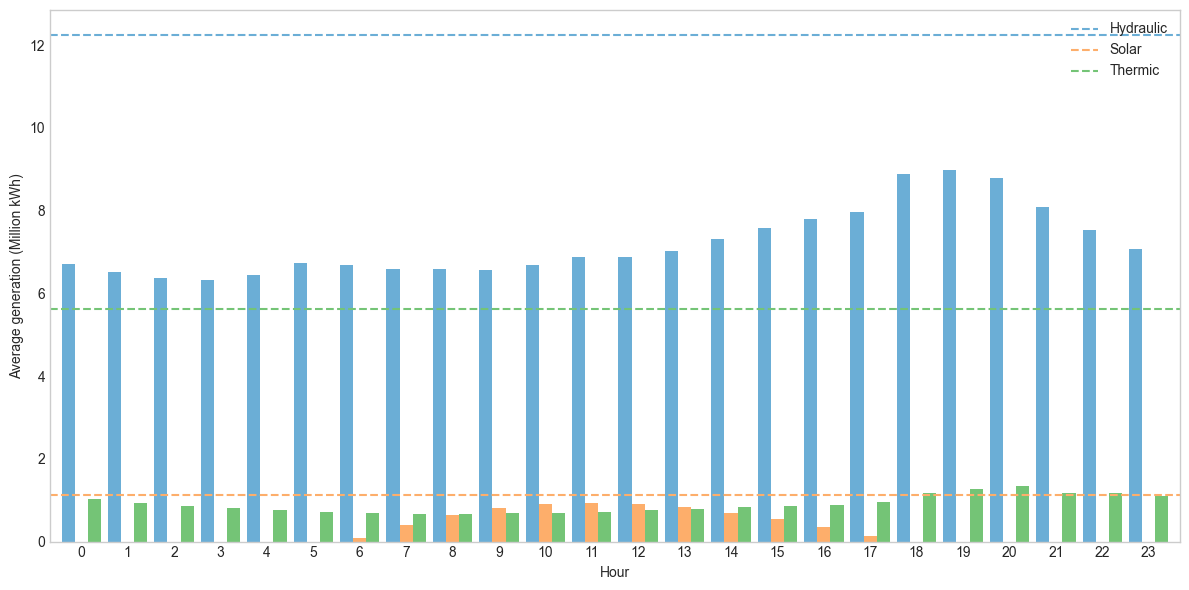

In [203]:
df_despacho_termica=df_despacho[df_despacho['CodigoElementoGeneracion'].isin(id_termica)]
df_despacho_hidraulica=df_despacho[df_despacho['CodigoElementoGeneracion'].isin(id_hidraulica)]
df_despacho_solar=df_despacho[df_despacho['CodigoElementoGeneracion'].isin(id_solar)]
# --- PLOT ---
import matplotlib.pyplot as plt
# Apply function to each technology dataframe
thermic_mean = mean_por_hora(df_despacho_termica)
solar_mean = mean_por_hora(df_despacho_solar)
hydraulic_mean = mean_por_hora(df_despacho_hidraulica)
cap_termica = df_desglose[df_desglose['Código SIC'].isin(id_termica)]['Capacidad Efectiva Neta [MW]'].sum()
cap_hidraulica = df_desglose[df_desglose['Código SIC'].isin(id_hidraulica)]['Capacidad Efectiva Neta [MW]'].sum()
cap_solar = df_desglose[df_desglose['Código SIC'].isin(id_solar)]['Capacidad Efectiva Neta [MW]'].sum()

cap_termica = cap_termica * 1000 / 1e6
cap_hidraulica = cap_hidraulica * 1000 / 1e6
cap_solar = cap_solar * 1000 / 1e6

# Merge results into a single dataframe
df_plot = (
    thermic_mean.rename(columns={"Valor": "Thermic"})
    .merge(
        solar_mean.rename(columns={"Valor": "Solar"}),
        on="hora"
    )
    .merge(
        hydraulic_mean.rename(columns={"Valor": "Hydraulic"}),
        on="hora"
    )
)

# Scale values to millions (1e6)
df_plot[["Thermic", "Solar", "Hydraulic"]] = (
    df_plot[["Thermic", "Solar", "Hydraulic"]] / 1e6
)

# Pastel colors
colors = ["#6baed6", "#fdae6b", "#74c476"]  # hydraulic, solar, thermic  # hydraulic, solar, thermic

ax = df_plot.set_index("hora")[["Hydraulic", "Solar", "Thermic"]].plot(
    kind="bar",
    figsize=(12,6),
    width=0.85,
    color=colors
)

ax.grid(False)

ax.axhline(cap_hidraulica, color="#6baed6", linestyle="--")
ax.axhline(cap_solar, color="#fdae6b", linestyle="--")
ax.axhline(cap_termica, color="#74c476", linestyle="--")

# Ajustar etiquetas del eje X (horas)
ax.set_xticks(range(len(df_plot)))
ax.set_xticklabels(df_plot['hora'], rotation=0)

plt.xlabel("Hour")
plt.ylabel("Average generation (Million kWh)")
plt.legend(["Hydraulic", "Solar", "Thermic"])
plt.tight_layout()
plt.show()



## este es el supuesto sobre los j

In [204]:
# Contar número de generadores por agente y tipo de generación
generadores_por_agente = df_desglose.groupby(['Tipo Generación', 'Agente Representante'])['Nombre Recurso'].nunique().reset_index()
generadores_por_agente.rename(columns={'Nombre Recurso': 'Num_Generadores'}, inplace=True)

# Contar cuántos agentes tienen 1, 2, 3... generadores por tipo de generación
resumen_generadores = generadores_por_agente.groupby(['Tipo Generación', 'Num_Generadores'])['Agente Representante']\
    .nunique().reset_index()

resumen_generadores.rename(columns={'Agente Representante': 'Num_Agentes'}, inplace=True)

resumen_generadores

,Tipo Generación,Num_Generadores,Num_Agentes
0,HIDRAULICA,1,2
1,HIDRAULICA,2,1
2,HIDRAULICA,5,1
3,HIDRAULICA,6,2
4,HIDRAULICA,9,1
5,SOLAR,1,6
6,SOLAR,4,1
7,TERMICA,1,8
8,TERMICA,2,5
9,TERMICA,3,2


In [205]:
df_desglose

,Código SIC,Nombre Recurso,Capacidad Efectiva Neta [MW],Factor de Conversión,Es Menor,Tipo Despacho,Combustible por Defecto,Fecha Operación,Municipio,Departamento,Agente Representante,Estado Recurso,Tipo Generación,Clasificación
20,TYP4,TERMOYOPAL G4,50.0,8.3937,NO,DC,GAS,2020-08-31,YOPAL,CASANARE,TERMOYOPAL GENERACION 2 S.A.S E.S.P.,OPERACIÓN,TERMICA,NORMAL
21,TYP3,TERMOYOPAL G3,50.0,8.4932,NO,DC,GAS,2020-08-31,YOPAL,CASANARE,TERMOYOPAL GENERACION 2 S.A.S E.S.P.,OPERACIÓN,TERMICA,NORMAL
27,GE32,GECELCA 32,270.0,10.2484,NO,DC,CARBON,2018-09-28,PTO. LIBERTADOR,CÓRDOBA,GENERADORA Y COMERCIALIZADORA DE ENERGIA DEL C...,OPERACIÓN,TERMICA,NORMAL
33,TSJ2,TASAJERO 2,170.0,10.1502,NO,DC,CARBON,2015-11-30,SAN CAYETANO,NORTE DE SANTANDER,TERMOTASAJERO DOS S.A. E.S.P.,OPERACIÓN,TERMICA,NORMAL
35,GEC3,GECELCA 3,164.0,10.1434,NO,DC,CARBON,2015-09-17,PTO. LIBERTADOR,CÓRDOBA,GENERADORA Y COMERCIALIZADORA DE ENERGIA DEL C...,OPERACIÓN,TERMICA,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,SMI1,SAN MIGUEL,50.0,1.4068,NO,DC,AGUA,2015-12-23,SAN LUIS,ANTIOQUIA,ISAGEN S.A. E.S.P.,OPERACIÓN,HIDRAULICA,FILO DE AGUA
480,PGUG,PAGUA,600.0,16.0307,NO,DC,AGUA,1986-12-01,LA MESA,CUNDINAMARCA,ENEL COLOMBIA SA ESP,OPERACIÓN,HIDRAULICA,NORMAL
494,PRDO,PRADO,51.0,0.4966,NO,DC,AGUA,1973-03-01,PRADO,TOLIMA,CELSIA COLOMBIA S.A. E.S.P.,OPERACIÓN,HIDRAULICA,NORMAL
496,GVIO,GUAVIO,1250.0,9.8367,NO,DC,AGUA,1993-03-19,UBALA,CUNDINAMARCA,ENEL COLOMBIA SA ESP,OPERACIÓN,HIDRAULICA,NORMAL


## este es el supuesto sobre las configuraciones

In [206]:
df_declarado

,CodigoVariable,Fecha,CodigoDuracion,UnidadMedida,CodigoPlanta,Configuracion,Valor,Código SIC,Tipo Generación
0,POF_Declarado,18/04/2025,PT1D,COP/kWh,ESMR,0,103.76,ESMR,HIDRAULICA
1,POF_Declarado,18/04/2025,PT1D,COP/kWh,TDR1,0,2306.46,TDR1,TERMICA
2,POF_Declarado,18/04/2025,PT1D,COP/kWh,URA1,0,250.00,URA1,HIDRAULICA
3,POF_Declarado,18/04/2025,PT1D,COP/kWh,CLMG,0,920.00,CLMG,HIDRAULICA
4,POF_Declarado,18/04/2025,PT1D,COP/kWh,TFL4,4,1534.69,TFL4,TERMICA
...,...,...,...,...,...,...,...,...,...
20029,POF_Declarado,18/06/2025,PT1D,COP/kWh,TSJ1,0,287.00,TSJ1,TERMICA
20030,POF_Declarado,18/06/2025,PT1D,COP/kWh,GVIO,0,103.50,GVIO,HIDRAULICA
20031,POF_Declarado,18/06/2025,PT1D,COP/kWh,MRL1,0,947.87,MRL1,TERMICA
20032,POF_Declarado,18/06/2025,PT1D,COP/kWh,TSR1,9,887.56,TSR1,TERMICA


In [207]:
archivo = "../datos/raw/PreciodeOfertaDeclarado.csv"
df_declarado = pd.read_csv(archivo, sep=";", encoding="utf-8")
df_declarado=df_declarado[
    df_declarado['CodigoPlanta'].isin(list(id_termica) + list(id_hidraulica) + list(id_solar))
]
df_declarado= pd.merge(df_declarado, df_desglose[['Código SIC', 'Tipo Generación']], left_on='CodigoPlanta', right_on='Código SIC')
df_declarado


,CodigoVariable,Fecha,CodigoDuracion,UnidadMedida,CodigoPlanta,Configuracion,Valor,Código SIC,Tipo Generación
0,POF_Declarado,18/04/2025,PT1D,COP/kWh,ESMR,0,103.76,ESMR,HIDRAULICA
1,POF_Declarado,18/04/2025,PT1D,COP/kWh,TDR1,0,2306.46,TDR1,TERMICA
2,POF_Declarado,18/04/2025,PT1D,COP/kWh,URA1,0,250.00,URA1,HIDRAULICA
3,POF_Declarado,18/04/2025,PT1D,COP/kWh,CLMG,0,920.00,CLMG,HIDRAULICA
4,POF_Declarado,18/04/2025,PT1D,COP/kWh,TFL4,4,1534.69,TFL4,TERMICA
...,...,...,...,...,...,...,...,...,...
19480,POF_Declarado,18/06/2025,PT1D,COP/kWh,TSJ1,0,287.00,TSJ1,TERMICA
19481,POF_Declarado,18/06/2025,PT1D,COP/kWh,GVIO,0,103.50,GVIO,HIDRAULICA
19482,POF_Declarado,18/06/2025,PT1D,COP/kWh,MRL1,0,947.87,MRL1,TERMICA
19483,POF_Declarado,18/06/2025,PT1D,COP/kWh,TSR1,9,887.56,TSR1,TERMICA


## los s

In [ ]:
# Contar número de configuraciones por planta y tipo de generación
config_por_planta = df_declarado.groupby(['Tipo Generación', 'CodigoPlanta'])['Configuracion'].nunique().reset_index()
config_por_planta.rename(columns={'Configuracion': 'Num_Configuraciones'}, inplace=True)

# Contar cuántas plantas tienen 1, 2, 3... configuraciones por tipo de generación
resumen_config = config_por_planta.groupby(['Tipo Generación', 'Num_Configuraciones'])['CodigoPlanta']\
    .nunique().reset_index()

resumen_config.rename(columns={'CodigoPlanta': 'Num_Plantas'}, inplace=True)
resumen_config.sort_values(['Tipo Generación', 'Num_Configuraciones'], inplace=True)
resumen_config

,Tipo Generación,Num_Configuraciones,Num_Plantas
0,HIDRAULICA,1,30
1,SOLAR,1,10
2,TERMICA,1,28
3,TERMICA,2,1
4,TERMICA,4,3
5,TERMICA,5,1
6,TERMICA,10,1
7,TERMICA,14,1


: 